# **Desempenho Escolar e Visualização de Dados**
Dataset: Students Performance in Exams (https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

Recursos Úteis:

 * Data Viz Project: https://datavizproject.com/input/c/ - Um catálogo visual de gráficos para explorar.

* From Data to Viz: https://www.data-to-viz.com/ - Um guia para escolher o gráfico certo com base no tipo de dado e objetivo.

* Documentação Seaborn: https://seaborn.pydata.org/ - Para detalhes sobre os parâmetros de estilo e plotagem.

* Documentação Matplotlib: https://matplotlib.org/stable/contents.html - Para controle fino sobre elementos do gráfico.



## **0: Configuração Inicial**

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Configurações padrão para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

print("Bibliotecas importadas e configurações aplicadas!")

# Carregar o dataset
try:
  path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

  df_performance = pd.read_csv(path+"/StudentsPerformance.csv")
    # Renomear colunas para facilitar o uso
  df_performance.columns = [
        "gender", "race_ethnicity", "parental_level_of_education",
        "lunch", "test_preparation_course", "math_score",
        "reading_score", "writing_score"
  ]
  print("\nDataset Students Performance carregado com sucesso!")
  print(df_performance.head())
  print("\nInformações do Dataset:")
  df_performance.info()
except FileNotFoundError:
  print("Erro: 'StudentsPerformance.csv' não encontrado.")


print("\nPré-processamento básico concluído.")

Bibliotecas importadas e configurações aplicadas!
Using Colab cache for faster access to the 'students-performance-in-exams' dataset.

Dataset Students Performance carregado com sucesso!
   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76     

### 1: Desafios de Decisão

Para cada cenário, você deverá:

1. Formular a pergunta estatística que a visualização deve responder;

2. Consultar o Data Viz Project ou From Data to Viz para identificar o tipo de gráfico mais adequado.

3. Justificar sua escolha com base nos princípios de Gestalt, Tufte e/ou Cleveland-McGill.

4. Implementar o gráfico usando matplotlib e seaborn. Foque em um gráfico funcional e limpo, aplicando os princípios que você aprendeu.

**Desafio 1.1: Distribuição das Notas em Matemática**

Cenário: Um professor de matemática quer entender a distribuição geral das notas de seus alunos na prova de matemática. Ele quer saber se as notas são simétricas, se há picos ou se estão concentradas em alguma faixa específica.

Sua Tarefa:

1. Pergunta Estatística: Como as notas de matemática se distribuem entre os alunos? Qual a sua forma, centro e dispersão?

2. Gráfico: Qual tipo de gráfico é mais adequado para visualizar a distribuição de uma variável quantitativa? Justifique sua escolha.

3. Implementação: Crie o gráfico em Python para a coluna math_score.

4. Análise: Descreva a distribuição das notas. Há evidências de assimetria? Qual a nota mais comum?


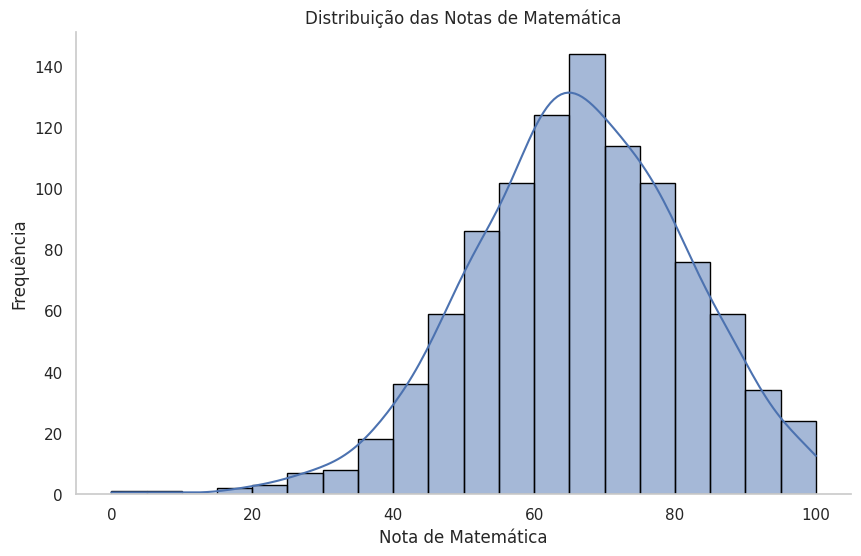

In [89]:
''' Escreva sua justificativa e análise aqui:

1. Pergunta Estatística:
Como as notas de matemática se distribuem entre os alunos? Qual é o formato da distribuição, onde está seu centro e qual é sua dispersão?

2. Gráfico:
O histograma é o gráfico mais adequado para visualizar a distribuição de uma variável quantitativa como a nota de matemática.
Ele permite observar distribuição, concentração de valores, dispersão e possíveis assimetrias.
Pela hierarquia de Cleveland e McGill, posição ao longo de uma escala comum é mais eficiente em analises.

4.Análise:
Existem evidencias de assimetria, as notas mais comuns estão nas faixas de 60 a 80
já as notas mais baixas possuem as menores frequencias, o que mostra uma distribuição
assimétrica positiva nesse contexto, em que o esperado é que os alunos possuam notas mais altas.

'''

# 3. Implementação:
plt.figure(figsize=(10, 6))
sns.histplot(df_performance["math_score"], bins=20, kde=True, edgecolor="black")
plt.title("Distribuição das Notas de Matemática")
plt.xlabel("Nota de Matemática")
plt.ylabel("Frequência")
sns.despine()
plt.grid(False)
plt.show()


**Desafio 1.2: Impacto do Nível de Escolaridade dos Pais nas Notas de Leitura**

Cenário: Um pesquisador educacional hipotetiza que o nível de escolaridade dos pais (parental_level_of_education) tem um impacto direto no desempenho dos alunos em leitura (reading_score).

Sua Tarefa:

1. Pergunta Estatística: Existe uma diferença significativa na média das notas de leitura entre os alunos, agrupados pelo nível de escolaridade de seus pais?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar uma variável quantitativa (nota) entre múltiplas categorias ordinais (nível de escolaridade)? Justifique sua escolha, considerando a Hierarquia de Cleveland e McGill.

3. Implementação: Crie o gráfico em Python. Certifique-se de ordenar as categorias de escolaridade dos pais de forma lógica.

4. Análise: O que o gráfico revela sobre a hipótese? Há uma tendência clara? Quais são as médias de leitura para cada grupo?



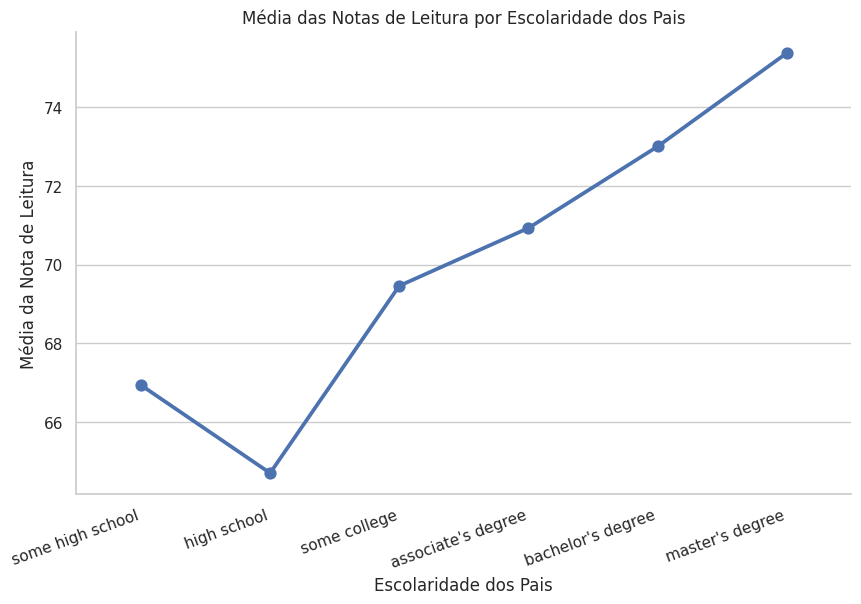

  parental_level_of_education  reading_score
0            some high school      66.938547
1                 high school      64.704082
2                some college      69.460177
3          associate's degree      70.927928
4           bachelor's degree      73.000000
5             master's degree      75.372881


In [90]:
''' Escreva sua justificativa e análise aqui:

1. Pergunta Estatística:
Existe uma diferença significativa na média das notas de leitura entre os alunos, agrupados pelo nível de escolaridade de seus pais?

2. Gráfico:
Um gráfico de pontos é ideal para comparar uma variável quantitativa entre múltiplas categorias ordinais
Ele também usa a posição em uma escala comum, o que leva a análises mais precisas segundo Cleveland e McGill
Além disso, como as variáveis categorias possuem uma ordem lógica, o gráfico de pontos ajuda a destacar a tendência sem exagerar diferenças visuais.

4. Análise:
O gráfico revela uma evidente relação entre o nível de escolaridade dos pais e o desempenho dos alunos em leitura.
Existe uma tendência de que, quanto maior o nível de escolaridade, maior o desempenho dos alunos nessa matéria.
A Média de leitura para cada grupo é:

some high school: 66.938547
high school: 64.704082
some college: 69.460177
associate's degree: 70.927928
bachelor's degree: 73.000000
master's degree: 75.372881

'''

# 3. Implementação:
ordem_educacao = [
    "some high school",
    "high school",
    "some college",
    "associate's degree",
    "bachelor's degree",
    "master's degree"
]

media_leitura = (
    df_performance.groupby("parental_level_of_education")["reading_score"]
    .mean()
    .reindex(ordem_educacao)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.pointplot(
    data=media_leitura,
    x="parental_level_of_education",
    y="reading_score"
)
plt.title("Média das Notas de Leitura por Escolaridade dos Pais")
plt.xlabel("Escolaridade dos Pais")
plt.ylabel("Média da Nota de Leitura")
plt.xticks(rotation=20, ha="right")
sns.despine()
plt.show()

print(media_leitura)


**Desafio 1.3: Relação entre Notas de Leitura e Escrita**

Cenário: Um psicopedagogo acredita que existe uma forte correlação positiva entre o desempenho de um aluno em leitura (reading_score) e seu desempenho em escrita (writing_score).

Sua Tarefa:

1. Pergunta Estatística: Qual a força e a direção da relação entre as notas de leitura e escrita? Há evidências de uma correlação linear?

2. Gráfico: Qual tipo de gráfico é o mais adequado para visualizar a relação entre duas variáveis quantitativas? Justifique sua escolha, focando na precisão perceptiva.

3. Implementação: Crie o gráfico em Python.

4. Análise: O gráfico suporta a hipótese de correlação positiva? Há algum outlier ou padrão interessante?



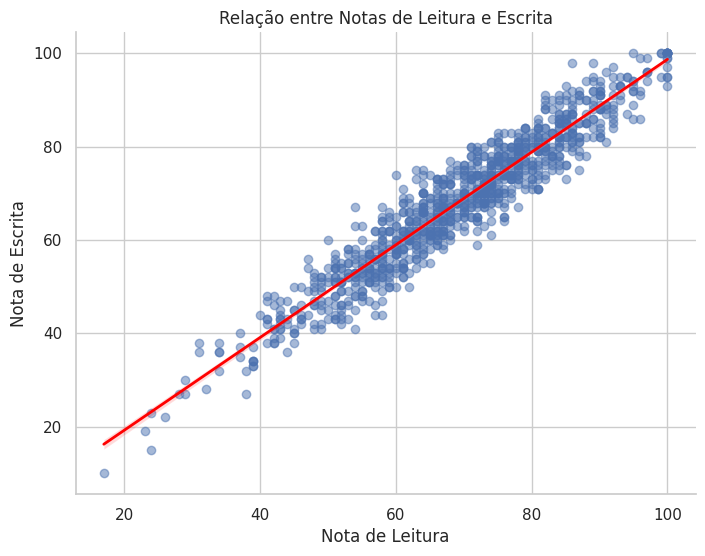

Correlação de Pearson: 0.9545980771462476


In [91]:
''' Escreva sua justificativa e análise aqui:

1. Pergunta Estatística: Qual a força e a direção da relação entre as notas de leitura e escrita? Há evidências de uma correlação linear?

2. Gráfico:
O gráfico mais adequado para visualizar a relação entre duas variáveis quantitativas é o gráfico de dispersão (Scatterplot)
Com ele podemos observar direção, forma, intensidade da associação e possíveis outliers. Pela hierarquia de Cleveland e McGill,
posição em dois eixos comuns é altamente precisa para comparação, o que torna o scatterplot apropriado.

4. Análise:
O gráfico mostra uma forte correlação leitura e escrita.
À medida que a nota de leitura aumenta, a nota de escrita tende a aumentar também.
Os pontos ficam próximos de uma tendência linear crescente, o que mostra uma correlação alta e positiva (Correlação de Pearson) de 0.95
Tem pontos afastados, mas não há outliers dominando o padrão geral.

'''

# 3. Implementação:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df_performance,
    x="reading_score",
    y="writing_score",
    scatter_kws={"alpha": 0.5,},
    line_kws={"linewidth": 2, "color": "red"}
)
plt.title("Relação entre Notas de Leitura e Escrita")
plt.xlabel("Nota de Leitura")
plt.ylabel("Nota de Escrita")
sns.despine()
plt.show()

print("Correlação de Pearson:", df_performance["reading_score"].corr(df_performance["writing_score"]))


**Desafio 1.4: Proporção de Gêneros e Preparação para o Teste**

Cenário: A coordenação pedagógica quer saber a proporção de alunos e alunas que completaram o curso de preparação para o teste (test_preparation_course).

Sua Tarefa:

1. Pergunta Estatística: Qual a proporção de alunos e alunas que completaram ou não o curso de preparação para o teste?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar proporções entre duas variáveis categóricas? Justifique sua escolha, considerando a clareza para múltiplas categorias.

3. Implementação: Crie o gráfico em Python.

4. Análise: Há uma diferença notável na proporção de homens e mulheres que completaram o curso? Qual grupo tem maior participação?



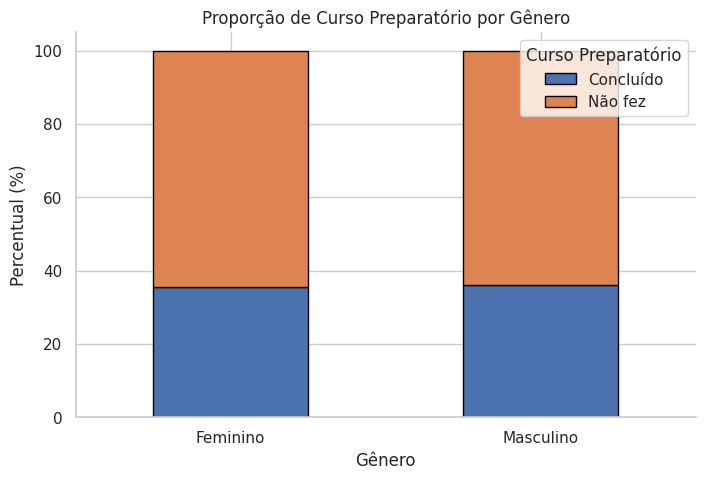

In [92]:
''' Escreva sua justificativa e análise aqui:

1. Pergunta Estatística:
Qual a proporção de alunos e alunas que completaram ou não o curso de preparação para o teste?

2. Gráfico:
O gráfico mais adequado nesse caso para comparar proporções entre duas variáveis categóricas seria o gráfico de barras
Com ele podemos comparar a composição percentual dentro de cada gênero de forma clara
A comparação por comprimento em uma escala comum é perceptivamente melhor do que áreas ou ângulos.

4. Análise:
O gráfico mostra que as proporções entre homens e mulheres que completaram o curso
são muito parecidas, portanto não há diferença notável entre os gêneros


'''

# 3. Implementação:
tabela = pd.crosstab(
    df_performance["gender"],
    df_performance["test_preparation_course"],
    normalize="index"
) * 100

tabela = tabela.rename(index={
    "female": "Feminino",
    "male": "Masculino"
})

tabela = tabela.rename(columns={
    "completed": "Concluído",
    "none": "Não fez"
})

tabela.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Proporção de Curso Preparatório por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Percentual (%)")
plt.xticks(rotation=0)
plt.legend(title="Curso Preparatório")
sns.despine()
plt.show()



**Desafio 1.5: Comparação de Notas Médias por Raça/Etnia em Todas as Matérias**

Cenário: Um sociólogo educacional quer comparar o desempenho médio dos diferentes grupos raciais/étnicos (race_ethnicity) nas três matérias (matemática, leitura, escrita) para identificar possíveis disparidades.

Sua Tarefa:

1. Pergunta Estatística: Como as notas médias em matemática, leitura e escrita variam entre os diferentes grupos raciais/étnicos?

2. Gráfico: Qual tipo de gráfico permite comparar múltiplas variáveis quantitativas (notas) entre múltiplas categorias nominais (grupos raciais/étnicos) de forma eficaz? Justifique sua escolha, pensando na clareza da comparação.

3. Implementação: Crie o gráfico em Python. Pode ser necessário reestruturar os dados (usar melt do pandas).

4. Análise: Quais grupos raciais/étnicos se destacam em quais matérias? Há padrões consistentes de desempenho?

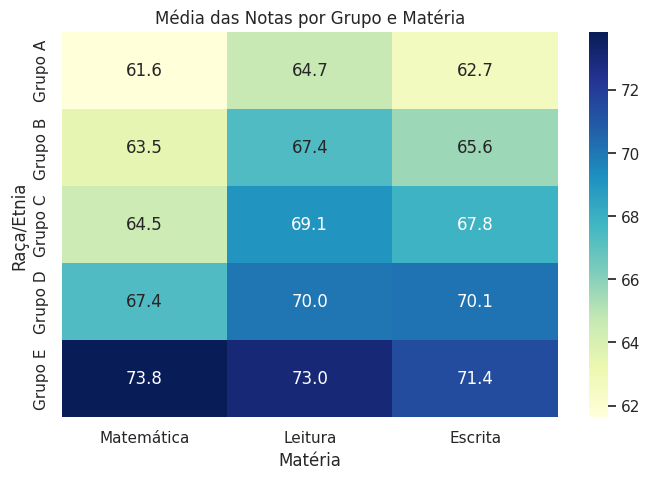

In [93]:
''' Escreva sua justificativa e análise aqui:

1. Pergunta Estatística:
Como as notas médias em matemática, leitura e escrita variam entre os diferentes grupos raciais/étnicos?

2. Gráfico:
O gráfico escolhido foi o heatmap, pois ele permite comparar simultaneamente múltiplas variáveis quantitativas (as notas de matemática, leitura e escrita)
entre diferentes categorias nominais (os grupos raciais/étnicos) de forma compacta e visual. A variação das cores facilita a identificação de
padrões, semelhanças e diferenças entre os grupos, tornando a análise mais eficiente quando se deseja observar o conjunto geral dos dados.


4. Análise:
O Heatmap mostra que existem variações nas médias das notas entre os grupos raciais/étnicos.
Os Grupos D e E têm valores mais altos nas 3 disciplinas e os grupos A e B ficam com as médias mais baixas, observa-se uma tendência de crescimento do grupo A até o grupo E.

'''

# 3. Implementação:
media_notas = df_performance.groupby("race_ethnicity")[
    ["math_score", "reading_score", "writing_score"]
].mean()

media_notas = media_notas.rename(
    index={
        "group A": "Grupo A",
        "group B": "Grupo B",
        "group C": "Grupo C",
        "group D": "Grupo D",
        "group E": "Grupo E"
    },
    columns={
        "math_score": "Matemática",
        "reading_score": "Leitura",
        "writing_score": "Escrita"
    }
)

plt.figure(figsize=(8, 5))
sns.heatmap(media_notas, annot=True, fmt=".1f", cmap="YlGnBu")

plt.title("Média das Notas por Grupo e Matéria")
plt.xlabel("Matéria")
plt.ylabel("Raça/Etnia")
plt.show()

### Parte 2: Desafios de Refatoração Estatística e Visual

Para cada cenário abaixo, você receberá um código Python que gera um gráfico com problemas de design. Sua tarefa é:

1. Analisar o gráfico gerado e identificar pelo menos 3 problemas com base nos princípios de Tufte (Data-Ink Ratio, Lie Factor, Chartjunk), Gestalt (Proximidade, Semelhança, Fechamento, etc.) e/ou Cleveland-McGill (eficácia da codificação).

2. Descrever os problemas identificados.

3. Modificar o código para refatorar o gráfico, aplicando os princípios para torná-lo mais honesto, eficiente e visualmente claro.



Desafio 2.1:  Comparação de Notas Médias de Matemática por Gênero

Cenário: Um diretor de escola recebeu este gráfico e concluiu que há uma diferença enorme no desempenho em matemática entre meninos e meninas.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico?

2. Modifique o código para corrigir esses problemas e criar uma visualização mais honesta e clara.

/tmp/ipykernel_37260/2082650646.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])


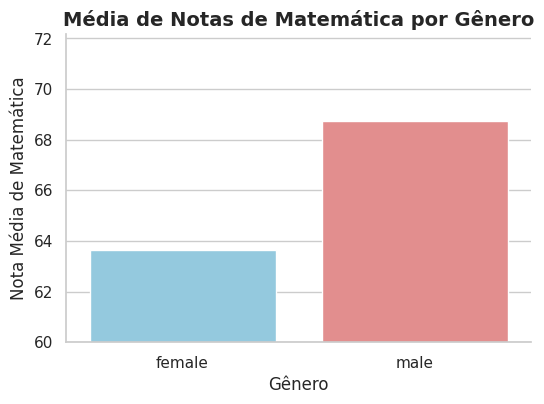

In [94]:
# Dados para o Desafio 2.1
df_gender_math = df_performance.groupby("gender")["math_score"].mean().reset_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])
ax.set_ylim(bottom=60) # Eixo Y começando alto
ax.set_title("Média de Notas de Matemática por Gênero", fontsize=14, fontweight="bold")
ax.set_xlabel("Gênero")
ax.set_ylabel("Nota Média de Matemática")
plt.show()

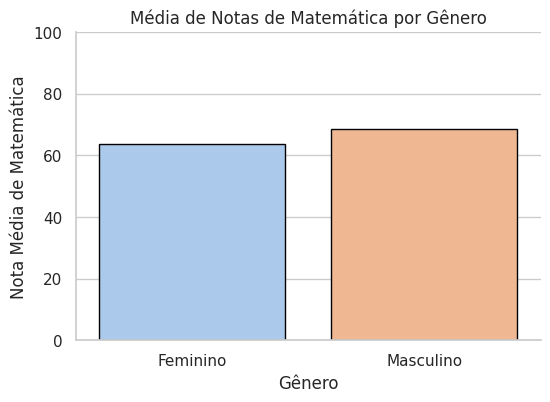

In [95]:
# 1. Problemas identificados:
#    a) O eixo começa em 60, o que exagera visualmente e aumenta o Lie Factor. (Tufte - Lie Factor)
#    b) O gráfico em barras só é confiável com uma linha de base comum em zero. (Cleveland-McGill)
#    c) O uso de barras preenchidas e cores contrastantes para apenas duas médias adiciona ênfase visual desnecessária. (Tufte - Data-Ink Ratio / Chartjunk)

# 2. Seu código Python refatorado:
df_gender_math = df_performance.groupby("gender", as_index=False)["math_score"].mean()

df_gender_math["gender"] = df_gender_math["gender"].replace({
    "female": "Feminino",
    "male": "Masculino"
})

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_gender_math,
    x="gender",
    y="math_score",
    hue="gender",
    palette="pastel",
    edgecolor="black",
    legend=False
)

ax.set_title("Média de Notas de Matemática por Gênero")
ax.set_xlabel("Gênero")
ax.set_ylabel("Nota Média de Matemática")
ax.set_ylim(0, 100)

sns.despine()
plt.show()


**Desafio 2.2: Impacto do Almoço na Nota de Escrita (Chartjunk e Cores Ineficazes)**

Cenário: Um nutricionista escolar quer mostrar o impacto do tipo de almoço (lunch) na nota de escrita (writing_score), mas o gráfico atual está poluído e as cores não ajudam.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, focando no Data-Ink Ratio e no uso de cores?

2. Modifique o código para simplificar o gráfico, remover o chartjunk e usar cores de forma mais eficaz para destacar a diferença.

/tmp/ipykernel_37260/2306030820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="lunch", y="writing_score", data=df_performance, palette=["green", "purple"])


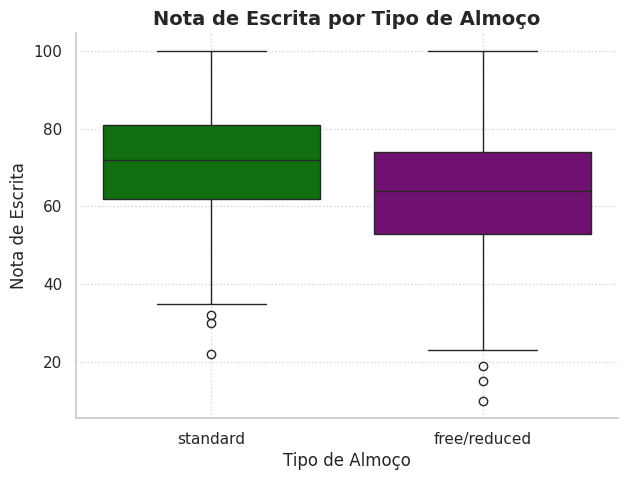

In [96]:
# Dados para o Desafio 2.2
plt.figure(figsize=(7, 5))
ax = sns.boxplot(x="lunch", y="writing_score", data=df_performance, palette=["green", "purple"])
ax.set_title("Nota de Escrita por Tipo de Almoço", fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo de Almoço")
ax.set_ylabel("Nota de Escrita")
ax.grid(True, linestyle=":", alpha=0.8) # Grade pesada
plt.show()

/tmp/ipykernel_37260/3239392384.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


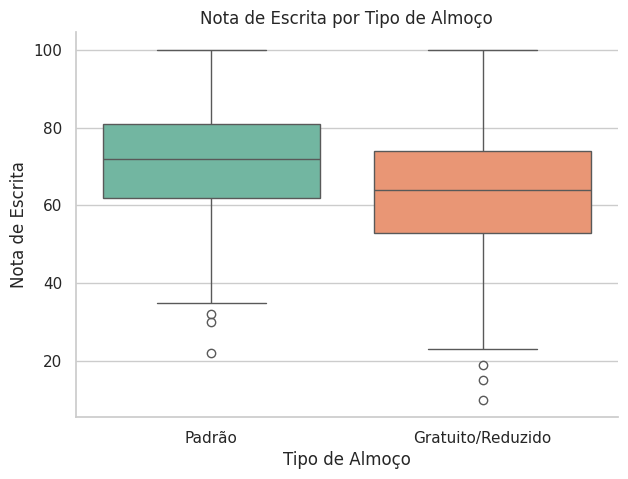

In [97]:
# 1. Problemas identificados:
#    a) A grade está muito pesada e polui o gráfico desnecessariamente. (Tufte - Data-Ink Ratio / Chartjunk)
#    b) As cores escolhidas não ajudam na leitura e criam excesso visual. (Tufte - Chartjunk)
#    c) As cores saturadas e a grade forte prejudicam a separação entre figura e fundo, fazendo com que elementos secundários concorram com os dados principais (Gestalt - Fechamento)

# 2. Seu código Python refatorado:
df_lunch = df_performance.copy()
df_lunch["lunch"] = df_lunch["lunch"].replace({
    "standard": "Padrão",
    "free/reduced": "Gratuito/Reduzido"
})

plt.figure(figsize=(7, 5))
ax = sns.boxplot(
    data=df_lunch,
    x="lunch",
    y="writing_score",
    palette="Set2"
)

ax.set_title("Nota de Escrita por Tipo de Almoço")
ax.set_xlabel("Tipo de Almoço")
ax.set_ylabel("Nota de Escrita")

sns.despine()
plt.show()

**Desafio 2.3: Distribuição de Notas de Leitura por Raça/Etnia (Sobrecarga Visual)**

Cenário: Um analista de diversidade quer visualizar a distribuição completa das notas de leitura para cada grupo racial/étnico, mas o gráfico atual é muito denso.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobrecarga visual e à clareza da comparação entre grupos?

2. Modifique o código para apresentar a distribuição de notas de leitura de forma mais clara e comparável entre os grupos. Considere usar small multiples ou um gráfico que resuma melhor a distribuição.


/tmp/ipykernel_37260/3061236733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="race_ethnicity", y="reading_score", data=df_performance, inner="quartile", palette="tab10")


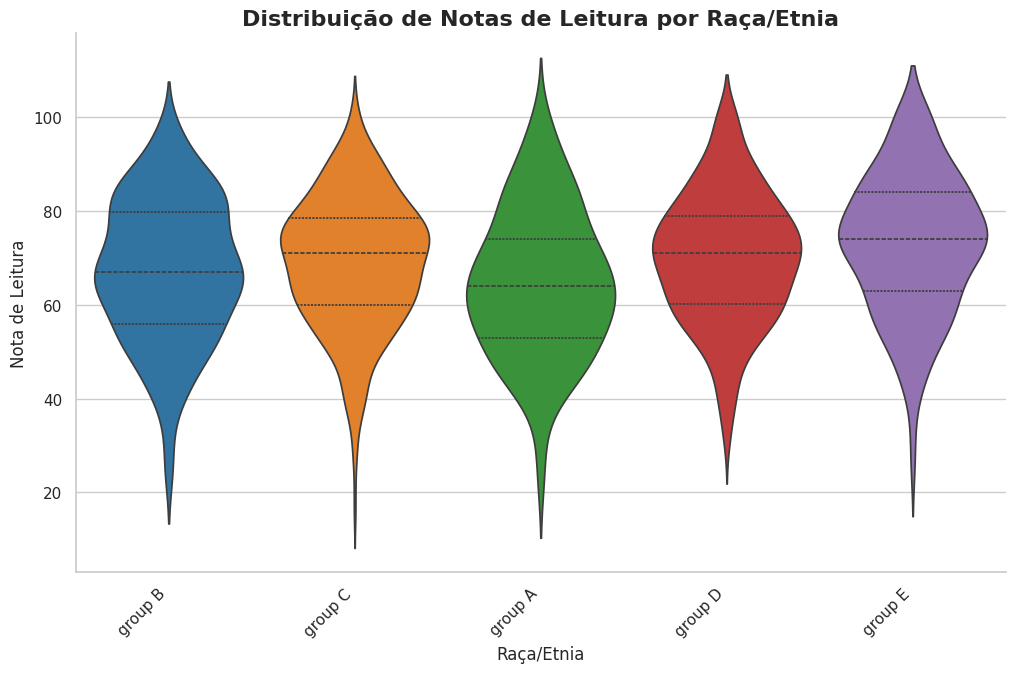

In [98]:
# Dados para o Desafio 2.3
plt.figure(figsize=(12, 7))
sns.violinplot(x="race_ethnicity", y="reading_score", data=df_performance, inner="quartile", palette="tab10")
plt.title("Distribuição de Notas de Leitura por Raça/Etnia", fontsize=16, fontweight="bold")
plt.xlabel("Raça/Etnia")
plt.ylabel("Nota de Leitura")
plt.xticks(rotation=45, ha='right')
plt.show()

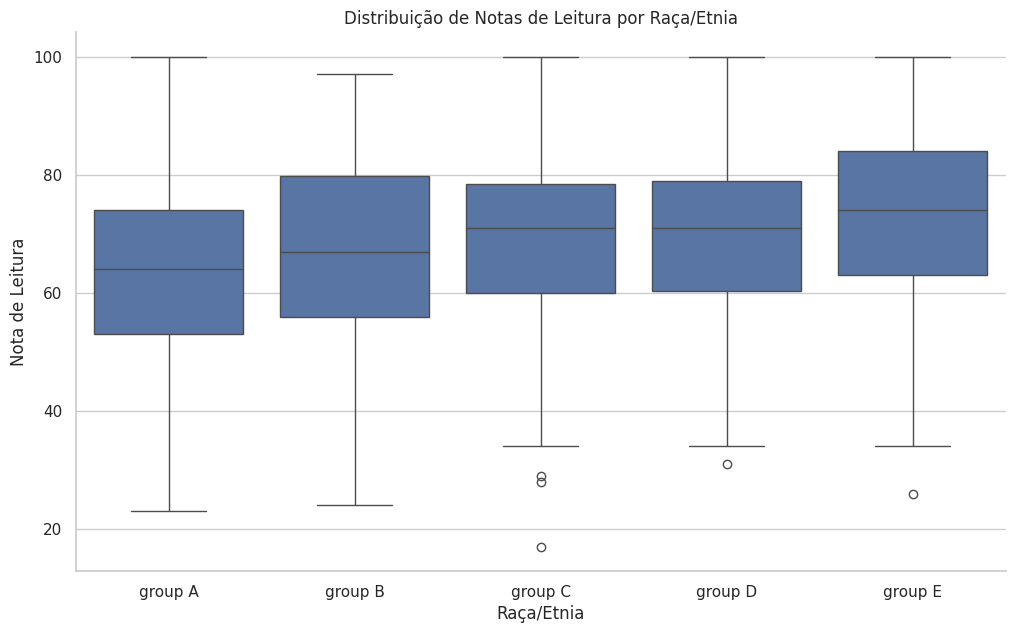

In [99]:
# 1. Problemas identificados:
#    a) Um Violinplot com 5 grupos e quartis internos gera excesso de informação visual para comparação rápida. (Cleveland-McGill)
#    b) Muitas cores aumentam a carga visual sem necessidade. (Tufte - Data-Ink Ratio / Chartjunk).
#    c) Comparar medianas e dispersões entre grupos fica mais difícil e confuso em um Violinplot igual a esse do que um boxplot simples.

# 2. Seu código Python refatorado:

plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df_performance,
    x="race_ethnicity",
    y="reading_score",
    order=["group A", "group B", "group C", "group D", "group E"],
)
plt.title("Distribuição de Notas de Leitura por Raça/Etnia")
plt.xlabel("Raça/Etnia")
plt.ylabel("Nota de Leitura")
sns.despine()
plt.show()

Desafio 2.4: Correlação entre Notas de Matemática e Leitura (Pontos Sobrepostos)

Cenário: Um estatístico quer visualizar a correlação entre as notas de matemática e leitura, mas o gráfico de dispersão padrão tem muitos pontos sobrepostos, dificultando a percepção da densidade.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobreposição de pontos e à percepção da densidade?

2. Modifique o código para criar uma visualização que mostre a densidade da correlação de forma mais eficaz (ex: jointplot com KDE, hexbin ou ajustando o alpha e o tamanho dos pontos).

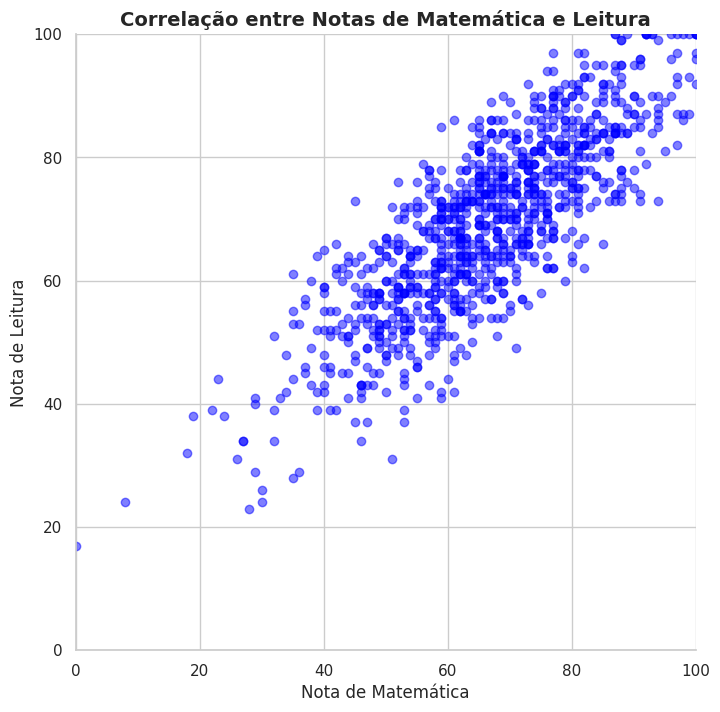

In [100]:
# Dados para o Desafio 2.4
plt.figure(figsize=(8, 8))
plt.scatter(x=df_performance["math_score"], y=df_performance["reading_score"], alpha=0.5, color="blue")
plt.title("Correlação entre Notas de Matemática e Leitura", fontsize=14, fontweight="bold")
plt.xlabel("Nota de Matemática")
plt.ylabel("Nota de Leitura")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.show()

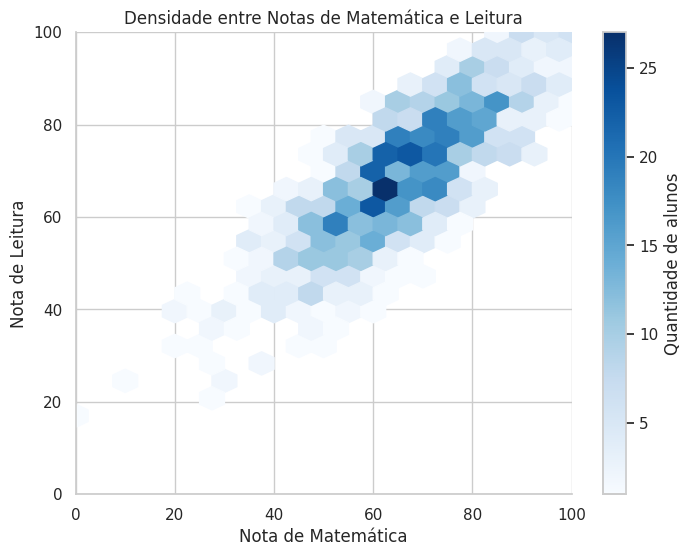

In [101]:
# 1. Problemas identificados:
#    a) Muitos pontos sobrepostos, o que dificulta perceber onde a densidade é maior.
#    b) Um scatterplot simples não mostra bem as regiões concentradas de dados
#    c) Falta recurso visual para resumir a tendencia além de pontos individuais

# 2. Seu código Python refatorado:
plt.figure(figsize=(8, 6))

hb = plt.hexbin(
    df_performance["math_score"],
    df_performance["reading_score"],
    gridsize=20,
    cmap="Blues",
    mincnt=1
)

plt.colorbar(hb, label="Quantidade de alunos")
plt.title("Densidade entre Notas de Matemática e Leitura")
plt.xlabel("Nota de Matemática")
plt.ylabel("Nota de Leitura")
plt.xlim(0, 100)
plt.ylim(0, 100)

sns.despine()
plt.show()

Desafio 2.5: Desempenho Geral por Curso de Preparação (Gráfico de Pizza com Múltiplas Variáveis)

Cenário: Um conselheiro estudantil quer visualizar o impacto do curso de preparação (test_preparation_course) no desempenho geral dos alunos, mas o gráfico atual tenta mostrar muitas coisas de uma vez de forma ineficaz.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico, especialmente em relação ao uso do gráfico de pizza para comparar médias e à representação de múltiplas variáveis?

2. Modifique o código para criar uma visualização mais eficaz que compare o desempenho médio em cada matéria (não apenas a média geral) entre os alunos que completaram e os que não completaram o curso de preparação.

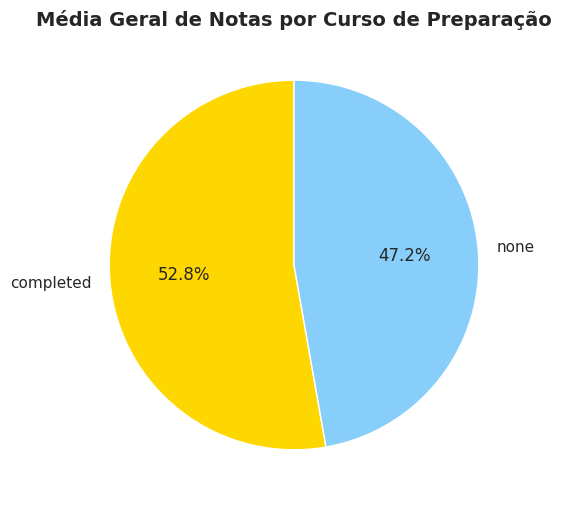

In [102]:
# Dados para o Desafio 2.5
df_prep_course = df_performance.groupby("test_preparation_course")[["math_score", "reading_score", "writing_score"]].mean().mean(axis=1).reset_index(name="overall_average_score")

plt.figure(figsize=(6, 6))
plt.pie(df_prep_course["overall_average_score"], labels=df_prep_course["test_preparation_course"], autopct="%1.1f%%", startangle=90, colors=["gold", "lightskyblue"])
plt.title("Média Geral de Notas por Curso de Preparação", fontsize=14, fontweight="bold")
plt.show()

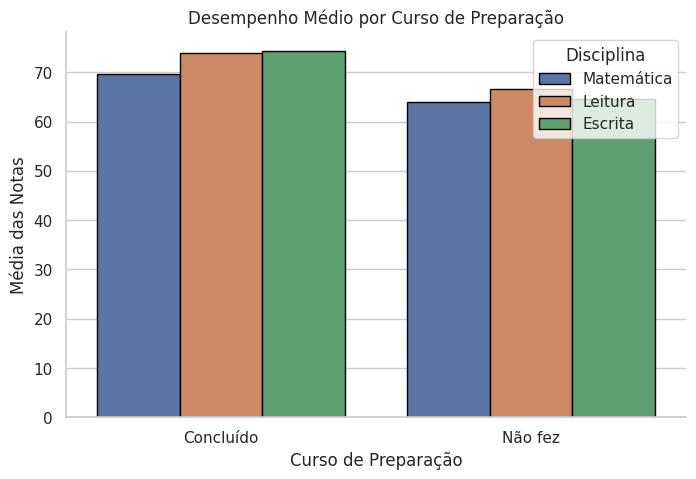

In [103]:
# 1. Problemas identificados:
#    a) O gráfico de pizza utiliza ângulo e área para comparar valores, o que é menos preciso do que usar comprimento em barras (Cleveland-McGill).
#    b) O percentual no gráfico de pizza sugere partes de um todo, mas as médias de notas não representam partes de um todo, o que torna a visualização conceitualmente inadequada (Tufte - Lie Factor).
#    c) Como juntou matemática, leitura e escrita em uma única média geral, o gráfico esconde diferenças entre as disciplinas e reduz a informação disponível.

# 2. Seu código Python refatorado:
df_prep = (
    df_performance.groupby("test_preparation_course")[["math_score", "reading_score", "writing_score"]]
    .mean()
    .reset_index()
)

df_prep["test_preparation_course"] = df_prep["test_preparation_course"].replace({
    "completed": "Concluído",
    "none": "Não fez"
})

df_prep = df_prep.melt(
    id_vars="test_preparation_course",
    var_name="disciplina",
    value_name="media_nota"
)

df_prep["disciplina"] = df_prep["disciplina"].replace({
    "math_score": "Matemática",
    "reading_score": "Leitura",
    "writing_score": "Escrita"
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_prep,
    x="test_preparation_course",
    y="media_nota",
    hue="disciplina",
    edgecolor="black"
)

ax.set_title("Desempenho Médio por Curso de Preparação")
ax.set_xlabel("Curso de Preparação")
ax.set_ylabel("Média das Notas")
ax.legend(title="Disciplina")

sns.despine()
plt.show()